In [163]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data.generator import generate_labeled_case
from src.decisioning.decision_engine import evaluate_trade
import pandas as pd
import matplotlib.pyplot as plt
import datetime

### Section 1: Generate data and run pipeline

In [164]:
trades = []

for _ in range(1000):
    trade = generate_labeled_case()
    prediction = evaluate_trade(trade)

    trades.append({
        **trade.model_dump(),
        **prediction
    })

### Section 2: Convert results to dataframe and run sanity checks

First 5 rows of the dataframe:


,trade_id,trade_timestamp,client_age,client_income,risk_tolerance,investment_experience,investment_objective,investment_time_horizon,investment_type,investment_amount,...,case_type,difficulty,compliance_probability,compliance_label,risk_score,confidence_score,escalation_level,priority_score,has_conflicting_signals,conflict_signals
0,TRADE-00f1841e,2026-04-03 02:12:40.508128,22,32353,High,Advanced,Balanced,Medium,Mutual Funds,11797.57,...,Risk Signal,Hard,1.0,True,25,0.650,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp..."
1,TRADE-abf503b3,2026-04-20 01:25:37.442634,44,160619,Low,Intermediate,Growth,Long,T-Bills,3440.32,...,Risk Signal,Hard,1.0,True,20,0.770,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp..."
2,TRADE-ac545ce6,2026-04-14 23:02:03.389634,79,100590,Low,Advanced,Preservation,Long,Mutual Funds,64830.06,...,Risk Signal,Hard,1.0,True,25,0.730,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp..."
3,TRADE-9d14f6b2,2026-04-14 21:28:28.231661,69,90968,Medium,Advanced,Balanced,Long,ETFs,77419.19,...,KYC Missing,Easy,1.0,False,55,0.645,urgent,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp..."
4,TRADE-23c79acf,2026-04-18 01:13:34.672944,80,135652,Low,Beginner,Preservation,Short,Bonds,72419.91,...,Risk Signal,Hard,1.0,True,25,0.610,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp..."


Summary statistics of the dataframe:


,trade_timestamp,client_age,client_income,investment_amount,compliance_probability,risk_score,confidence_score,priority_score
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,80.000000
mean,2026-04-16 09:29:10.114003,48.511000,113711.731000,50455.935610,0.871300,24.410000,0.733165,132.130000
min,2026-04-01 12:29:25.360604,18.000000,30099.000000,371.860000,0.000000,0.000000,0.580000,33.600000
25%,2026-04-08 20:08:22.462200,33.000000,70505.000000,26189.542500,1.000000,15.000000,0.670000,141.375000
50%,2026-04-16 01:55:50.839133,48.000000,112289.500000,50136.065000,1.000000,20.000000,0.730000,142.850000
75%,2026-04-23 20:15:14.536686,63.000000,158321.500000,74499.207500,1.000000,30.000000,0.790000,149.850000
max,2026-05-01 11:04:25.694053,80.000000,199996.000000,99850.200000,1.000000,100.000000,0.940000,162.750000
std,NaN,17.905823,49819.775938,28729.713277,0.262212,19.812734,0.082326,37.456041


true_compliance
True     827
False    173
Name: count, dtype: int64

...

,trade_id,trade_timestamp,client_age,client_income,risk_tolerance,investment_experience,investment_objective,investment_time_horizon,investment_type,investment_amount,...,case_type,difficulty,compliance_probability,compliance_label,risk_score,confidence_score,escalation_level,priority_score,has_conflicting_signals,conflict_signals
3,TRADE-9d14f6b2,2026-04-14 21:28:28.231661,69,90968,Medium,Advanced,Balanced,Long,ETFs,77419.19,...,KYC Missing,Easy,1.0,False,55,0.645,urgent,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp..."
5,TRADE-7bd2cf4a,2026-04-18 01:01:10.998451,66,58538,High,Beginner,Growth,Medium,T-Bills,33937.17,...,Risk Signal,Hard,1.0,False,25,0.750,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp..."
15,TRADE-1289a448,2026-04-15 21:36:28.637359,54,64640,Low,Advanced,Preservation,Medium,Stocks,86019.51,...,Suitability Violation,Medium,0.4,False,65,0.855,priority,149.85,False,"{'risk_too_high_for_profile': True, 'too_compl..."
19,TRADE-c1be3c18,2026-04-27 04:03:33.183933,45,152911,High,Beginner,Preservation,Short,Options,70687.53,...,Insufficient Experience,Medium,0.5,False,70,0.855,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp..."
21,TRADE-1d713057,2026-04-22 18:28:46.782343,39,118493,Low,Advanced,Income,Long,Options,59867.60,...,Suitability Violation,Easy,0.4,False,55,0.855,priority,142.85,False,"{'risk_too_high_for_profile': True, 'too_compl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965,TRADE-d5e2cb0e,2026-04-15 15:28:47.449629,77,120401,Medium,Beginner,Income,Medium,T-Bills,62444.94,...,KYC Missing,Easy,0.2,False,55,0.685,urgent,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp..."
975,TRADE-b9e0b21c,2026-04-19 02:29:36.757717,66,90367,High,Intermediate,Preservation,Long,Stocks,89233.38,...,KYC Missing,Medium,1.0,False,65,0.810,urgent,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp..."
979,TRADE-ffae5189,2026-04-06 03:53:27.291702,80,126025,Low,Intermediate,Growth,Short,Options,34192.90,...,Suitability Violation,Medium,0.2,False,65,0.775,priority,152.25,False,"{'risk_too_high_for_profile': True, 'too_compl..."
989,TRADE-7f9742bc,2026-04-17 14:19:00.372024,60,124126,Low,Intermediate,Income,Medium,Options,51257.69,...,Suitability Violation,Easy,0.4,False,55,0.895,priority,141.65,False,"{'risk_too_high_for_profile': True, 'too_compl..."


Cases with low confidence scores:


,trade_id,trade_timestamp,client_age,client_income,risk_tolerance,investment_experience,investment_objective,investment_time_horizon,investment_type,investment_amount,...,case_type,difficulty,compliance_probability,compliance_label,risk_score,confidence_score,escalation_level,priority_score,has_conflicting_signals,conflict_signals
75,TRADE-d5d15e8e,2026-04-22 22:48:14.532068,29,61074,High,Advanced,Preservation,Medium,GICs,67051.56,...,Risk Signal,Hard,1.0,True,30,0.58,queue,33.6,False,"{'risk_too_high_for_profile': False, 'too_comp..."
268,TRADE-eb608ad9,2026-04-10 19:22:54.536045,31,59868,Medium,Advanced,Income,Long,GICs,91935.29,...,Risk Signal,Hard,1.0,True,30,0.58,queue,33.6,False,"{'risk_too_high_for_profile': False, 'too_comp..."
283,TRADE-09568d94,2026-04-11 21:10:57.391009,42,140041,High,Beginner,Income,Short,GICs,42995.16,...,Risk Signal,Hard,1.0,True,30,0.58,queue,33.6,False,"{'risk_too_high_for_profile': False, 'too_comp..."
565,TRADE-0d899bd9,2026-04-09 15:52:10.914871,47,192489,Low,Advanced,Growth,Medium,GICs,67381.38,...,Risk Signal,Hard,1.0,True,30,0.58,queue,33.6,False,"{'risk_too_high_for_profile': False, 'too_comp..."
713,TRADE-74073bd2,2026-04-18 17:22:49.936538,41,37352,Low,Advanced,Balanced,Long,T-Bills,49866.14,...,Risk Signal,Hard,1.0,True,30,0.58,queue,33.6,False,"{'risk_too_high_for_profile': False, 'too_comp..."
722,TRADE-4f843f11,2026-04-19 04:40:33.684825,29,171156,High,Advanced,Income,Short,GICs,66582.73,...,Risk Signal,Hard,1.0,True,40,0.58,queue,40.6,False,"{'risk_too_high_for_profile': False, 'too_comp..."
787,TRADE-df758e27,2026-04-21 00:02:45.162523,33,89382,High,Intermediate,Income,Short,Bonds,92960.81,...,Risk Signal,Hard,1.0,True,30,0.58,queue,33.6,False,"{'risk_too_high_for_profile': False, 'too_comp..."
920,TRADE-28b9f571,2026-04-30 09:40:36.723542,69,91937,Medium,Advanced,Growth,Medium,T-Bills,28351.77,...,Risk Signal,Hard,1.0,False,40,0.58,queue,40.6,False,"{'risk_too_high_for_profile': False, 'too_comp..."
984,TRADE-19079c28,2026-04-29 05:28:17.300711,72,36844,Low,Intermediate,Growth,Short,Bonds,55263.62,...,Risk Signal,Hard,0.7,True,30,0.58,queue,33.6,False,"{'risk_too_high_for_profile': False, 'too_comp..."
992,TRADE-ade3c949,2026-04-11 13:45:33.313622,77,79651,Medium,Beginner,Balanced,Long,T-Bills,76068.33,...,Risk Signal,Hard,1.0,False,30,0.58,queue,33.6,False,"{'risk_too_high_for_profile': False, 'too_comp..."


Priority score distribution:


<Axes: >

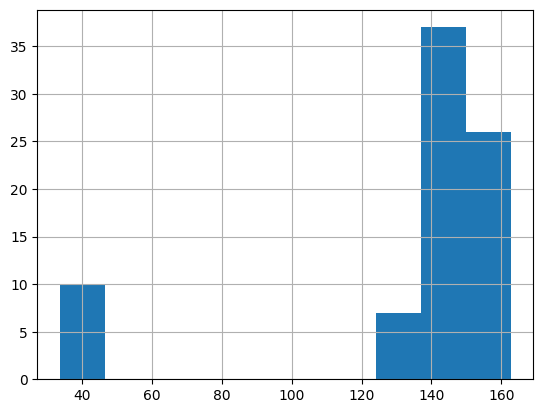

In [165]:
df = pd.DataFrame(trades)

print("First 5 rows of the dataframe:")
display(df.head())

print("Summary statistics of the dataframe:")
display(df.describe())

display(df["true_compliance"].value_counts())
display(df["escalation_level"].value_counts())

print("Cases with compliance prediction of False:")
display(df[df["compliance_label"] == False])

print("Cases with low confidence scores:")
display(df[df["confidence_score"] < 0.6])

print("Priority score distribution:")
display(df["priority_score"].hist())

### Section 3: Basic Metrics

In [166]:
tp = ((df["compliance_label"] == False) & (df["true_compliance"] == False)).sum()
tn = ((df["compliance_label"] == True) & (df["true_compliance"] == True)).sum()
fp = ((df["compliance_label"] == False) & (df["true_compliance"] == True)).sum()
fn = ((df["compliance_label"] == True) & (df["true_compliance"] == False)).sum()

accuracy = (tp + tn) / len(df)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1_score:.2f}")

print("\n'Urgent' rate: " + str(len(df[df["escalation_level"]=="urgent"])/len(df)))
print("'Priority' rate: " + str(len(df[df["escalation_level"]=="priority"])/len(df)))
print("'Queue' rate: " + str(len(df[df["escalation_level"]=="queue"])/len(df)))
print("'No flag' rate: " + str(len(df[df["escalation_level"]=="none"])/len(df)))
print("Rate of high risk trades flagged as 'Urgent' or 'Priority': " + str(len(df[(df["risk_score"] > 70) & (df["escalation_level"].isin(["urgent", "priority"]))])/len(df[df["risk_score"] > 70])))
print("Rate of low confidence trades flagged as 'Queue': " + str(len(df[(df["confidence_score"] < 0.6) & (df["escalation_level"]=="queue")])/len(df[df["confidence_score"] < 0.6])))

print("\nTrue compliance rates by risk bucket:")
df["risk_bucket"] = pd.cut(df["risk_score"], bins=[0, 30, 70, 100], labels=["Low", "Medium", "High"], include_lowest=True)
display(df.groupby("risk_bucket")["true_compliance"].value_counts(normalize=True))

df.groupby(pd.cut(df["confidence_score"], bins=5))["true_compliance"].mean()

Accuracy: 0.92
Precision: 0.70
Recall: 0.91
F1 Score: 0.79

'Urgent' rate: 0.075
'Priority' rate: 0.07
'Queue' rate: 0.01
'No flag' rate: 0.845
Rate of high risk trades flagged as 'Urgent' or 'Priority': 1.0
Rate of low confidence trades flagged as 'Queue': 1.0

True compliance rates by risk bucket:


risk_bucket  true_compliance
Low          True               0.994859
             False              0.005141
Medium       False              0.726804
             True               0.273196
High         False              1.000000
Name: proportion, dtype: float64

confidence_score
(0.58, 0.652]     0.870466
(0.652, 0.724]    0.900709
(0.724, 0.796]    0.912752
(0.796, 0.868]    0.641379
(0.868, 0.94]     0.487805
Name: true_compliance, dtype: float64

### Section 4: Save data to CSV

In [167]:
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
df.to_csv(f"./outputs/data_with_predictions_{timestamp}.csv", index=False)